In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from PIL import Image
from gwpy.timeseries import TimeSeries
import torch

    preprocessing:

https://iopscience.iop.org/article/10.1088/1361-6382/ab685e

https://www.kaggle.com/code/mistag/data-preprocessing-with-gwpy/notebook

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def tsplot(y, lags=15):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    
    # layout
    fig = plt.figure(figsize=(10, 4))
    layout = (2, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
    acf_ax = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))
    
    # ts plot
    y.plot(ax=ts_ax)
    ts_ax.set_title('Time series');
    
    # acf, pacf
    plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
    plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5, method='ywm') 


In [5]:
def preprocess(d1, d2, d3, bandpass=False, lf=20, hf=350,tukey=0.2):
    white_d1 = d1.whiten(window=("tukey",tukey))
    white_d2 = d2.whiten(window=("tukey",tukey))
    white_d3 = d3.whiten(window=("tukey",tukey))
    if bandpass: # bandpass filter
        bp_d1 = white_d1.bandpass(lf, hf) 
        bp_d2 = white_d2.bandpass(lf, hf)
        bp_d3 = white_d3.bandpass(lf, hf)
        return bp_d1, bp_d2, bp_d3
    else: # only whiten
        return white_d1, white_d2, white_d3

In [5]:

def read_file(fname):
    data = np.load(fname)
    return data

In [78]:
len(raw_d1)

4096

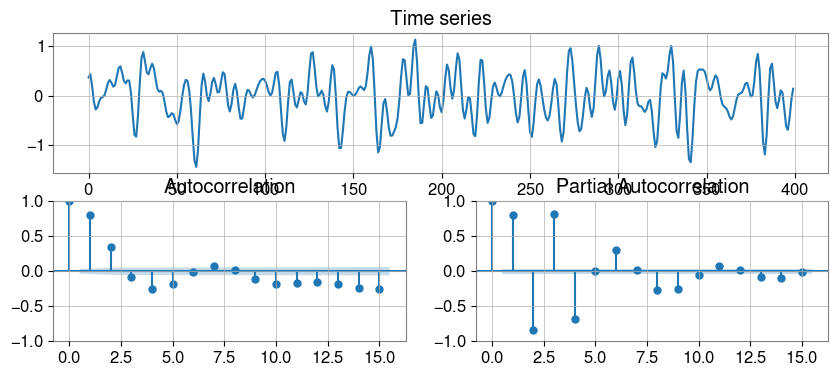

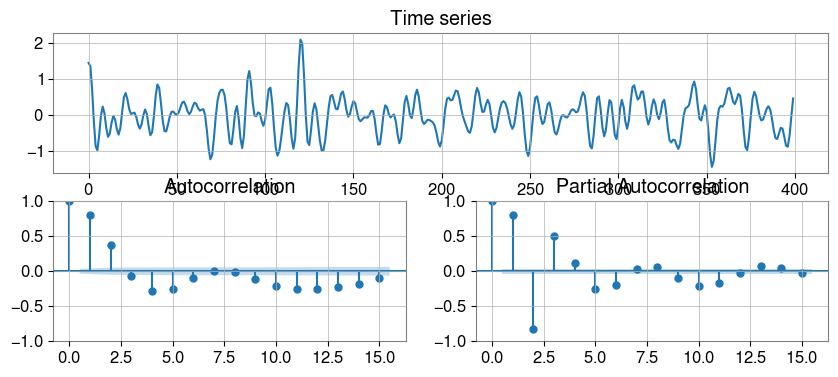

In [34]:
#data1 = read_file("00000e74ad.npy")
#data2 = read_file("../mvi/g2net-gravitational-wave-detection/train/0/0/0/00007a006a.npy")
#data_process1 = preprocess(data1[0],data1[1], data1[2],bandpass=True,tukey=0.2)
#data_process2 = preprocess(data2[0],data2[1], data2[2],bandpass=True,tukey=0.2)
#tsplot(data_process1[0][1900:2300])
#tsplot(data_process2[0][1900:2300])
# pokud je to jednorozměrná časová řada

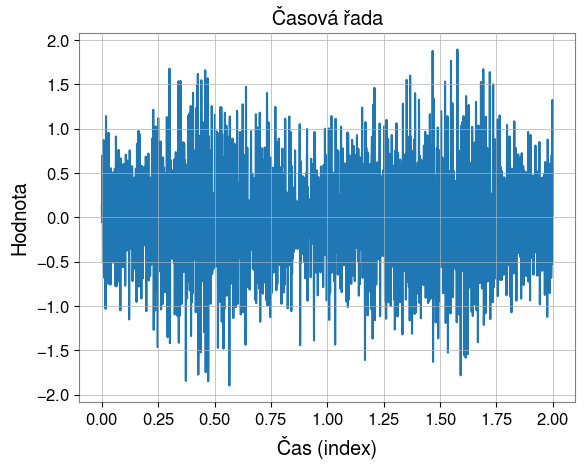

In [23]:
plt.plot(data_process[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

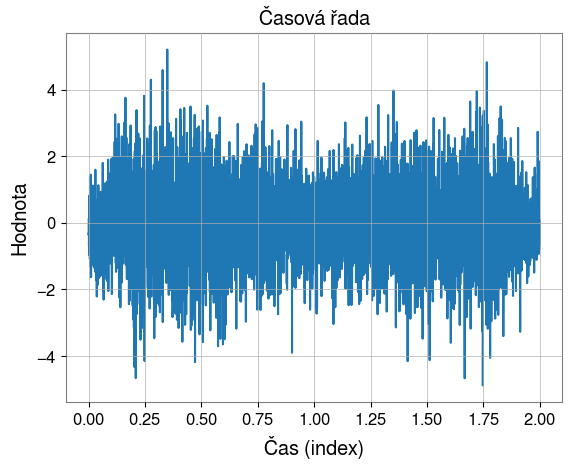

In [14]:
plt.plot(data_process[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

In [48]:
from scipy import signal
from scipy.signal.windows import tukey
window = tukey(4096, 0.1)
sos = signal.butter(8, [20, 500], btype="bandpass", output="sos", fs=2048)
def bandpass(x, lf=20, hf=500, order=8, sr=2048, filter_settings = 0):
    '''
    Cell 33 of https://www.gw-openscience.org/LVT151012data/LOSC_Event_tutorial_LVT151012.html
    https://scipy-cookbook.readthedocs.io/items/ButterworthBandpass.html
    '''
    #no butter which means no normal, only tukey and scaling
    #x *= window
    for i in range(3):
        x[i] = signal.sosfilt(sos, x[i])# * normalization
    return x
    
    #sos = signal.butter(order, [lf, hf], btype="bandpass", output="sos", fs=sr)
    #normalization = np.sqrt((hf - lf) / (sr / 2))
        #print(x)
    #x *= window
    #for i in range(3):
    #    x[i] = signal.sosfilt(sos, x[i]) * normalization
    #return x
    

In [25]:
scaling = [1.5e-20, 1.5e-20, 0.5e-20]
def preprocess(data, bandpass_number):
    p1, p2, p3 = bandpass(data, filter_settings = bandpass_number)

    p1 = p1 / scaling[0]
    p2 = p2 / scaling[1]
    p3 = p3 / scaling[2]
    return p1, p2, p3

In [ ]:
scaling = [1.5e-20, 1.5e-20, 0.5e-20]
def preprocess_scale(data, bandpass_number):
    p1 = data[0]
    p2 = data[1]
    p3 = data[2]
    
    p1 = p1 / scaling[0]
    p2 = p2 / scaling[1]
    p3 = p3 / scaling[2]
    return p1, p2, p3

In [28]:
from torch.utils.data import Dataset
import torch
import numpy as np
import pandas as pd
import os
import glob

class TimeSeriesDataset(Dataset):
    def __init__(self, root_dir, labels_csv, return_raw_only, return_process_only):
        self.root_dir = root_dir
        self.return_raw_only = return_raw_only
        self.return_process_only=return_process_only
        df = pd.read_csv(labels_csv)
        self.label_map = {str(name).replace('.npy', ''): int(label)
                          for name, label in zip(df.iloc[:, 0], df.iloc[:, 1])}

        all_files = glob.glob(os.path.join(root_dir, "**", "*.npy"), recursive=True)

        self.files = [f for f in all_files
                      if os.path.splitext(os.path.basename(f))[0] in self.label_map]
        self.process_number = 10
    
    def __len__(self):
        return len(self.files)


    def __getitem__(self, idx):
        file = self.files[idx]
        data = read_file(file)
        #data = np.load(file)  # data[0], data[1], data[2]
        d1, d2, d3 = data
    
        if self.return_raw_only:
            stacked = np.stack([d1, d2, d3], axis=0)
        elif self.return_process_only:
            p1, p2, p3 = preprocess(data, self.process_number)
            stacked = np.stack([p1, p2, p3], axis=0)
        else:
            p1, p2, p3 = preprocess(d1, d2, d3)
            stacked = np.stack([d1, p1, d2, p2, d3, p3], axis=0)
    
        X = torch.tensor(stacked, dtype=torch.float32)
        base = os.path.splitext(os.path.basename(file))[0]
        y = torch.tensor([self.label_map[base]], dtype=torch.float32)
        return X, y#, base


In [8]:
import torch
import torch.nn as nn

class ConcatBlockConv5(nn.Module):
    def __init__(self, in_ch, out_ch, k=32, act=nn.SiLU):
        super().__init__()
        
        def make_block(kernel_size):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding='same'),
                nn.BatchNorm1d(out_ch),
                act()
            )

        self.c1 = make_block(k)          # k=32
        self.c2 = make_block(k * 2)      # k=64
        self.c3 = make_block(k // 2)     # k=16
        self.c4 = make_block(k // 4)     # k=8
        self.c5 = make_block(k * 4)      # k=128
        
        c6_in_channels = (out_ch * 5) + in_ch
        
        self.c6 = nn.Sequential(
            nn.Conv1d(c6_in_channels, out_ch, kernel_size=1),
            nn.BatchNorm1d(out_ch),
            act()
        )

    def forward(self, x):
        x1 = self.c1(x)
        x2 = self.c2(x)
        x3 = self.c3(x)
        x4 = self.c4(x)
        x5 = self.c5(x)

        out = torch.cat([x1, x2, x3, x4, x5, x], dim=1)
        
        return self.c6(out)

In [9]:
class GWNet(nn.Module):
    def __init__(self, channels=3, classes=1):
        super().__init__()

        self.b1 = ConcatBlockConv5(channels, 32, k=32)
        self.p1 = nn.MaxPool1d(2)

        self.b2 = ConcatBlockConv5(32, 64, k=32)
        self.p2 = nn.MaxPool1d(2)

        self.b3 = ConcatBlockConv5(64, 128, k=32)
        self.p3 = nn.MaxPool1d(2)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, classes)

    def forward(self, x):
        x = self.p1(self.b1(x))
        x = self.p2(self.b2(x))
        x = self.p3(self.b3(x))
        x = self.gap(x).squeeze(-1)
        return self.fc(x)

In [54]:
from scipy import signal
from scipy.signal.windows import tukey
window = tukey(4096, 0.1)
sos = signal.butter(8, [20, 500], btype="bandpass", output="sos", fs=2048)
def bandpass(x, lf=20, hf=500, order=8, sr=2048, filter_settings = 0):
    '''
    Cell 33 of https://www.gw-openscience.org/LVT151012data/LOSC_Event_tutorial_LVT151012.html
    https://scipy-cookbook.readthedocs.io/items/ButterworthBandpass.html
    '''
    #no butter which means no normal, only tukey and scaling
    x *= window
    for i in range(3):
        x[i] = signal.sosfilt(sos, x[i])# * normalization
    return x
    
    #sos = signal.butter(order, [lf, hf], btype="bandpass", output="sos", fs=sr)
    #normalization = np.sqrt((hf - lf) / (sr / 2))
        #print(x)
    #x *= window
    #for i in range(3):
    #    x[i] = signal.sosfilt(sos, x[i]) * normalization
    #return x

In [59]:
file_path = "00000e74ad.npy" # <--- PUT YOUR REAL FILE PATH HERE

# C. Run the pipeline
# Step 1: Read Raw
data = read_file(file_path)


In [60]:
processed_data_bandpass = preprocess(data)

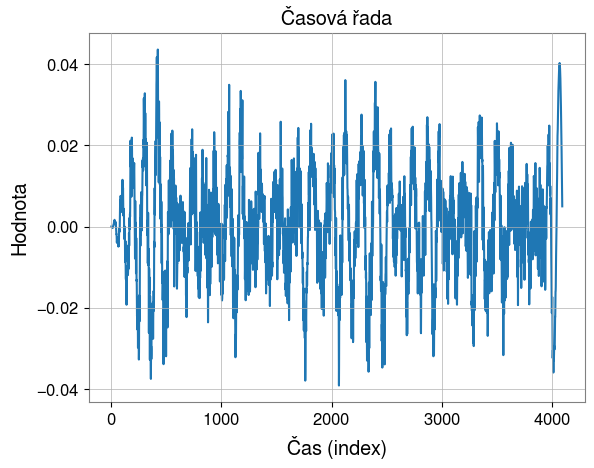

In [61]:
plt.plot(processed_data_bandpass[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

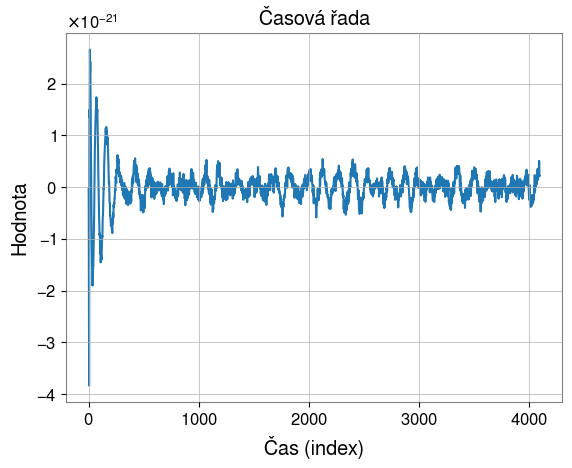

In [51]:
plt.plot(processed_data_bandpass[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

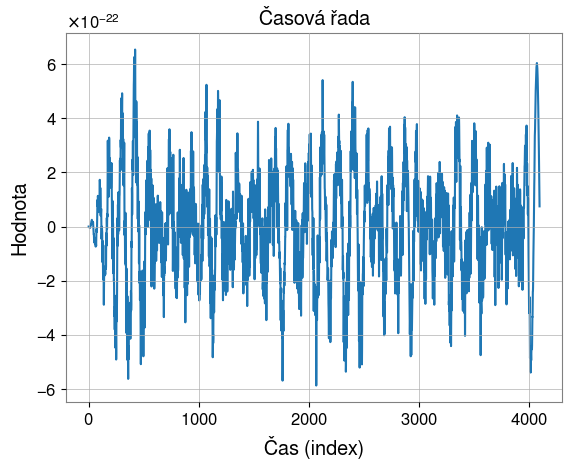

In [55]:
plt.plot(processed_data_bandpass[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

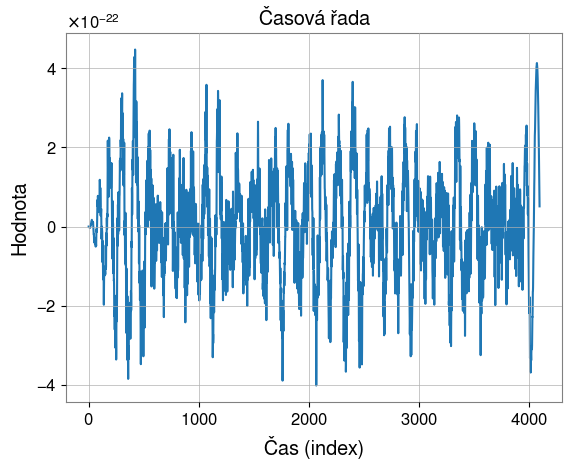

In [59]:
plt.plot(data[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

In [58]:
scaling = [1.5e-20, 1.5e-20, 0.5e-20]
def preprocess(data):#, bandpass=False, lf=20, hf=350,tukey=0.2):
    p1, p2, p3 = bandpass(data)
    #p1 = butter_highpass(d1)
    #p2 = butter_highpass(d2)
    #p3 = butter_highpass(d3)
    #scaling = tf.constant([1.5e-20, 1.5e-20, 0.5e-20], dtype=tf.float64)
    p1 = p1 / scaling[0]
    p2 = p2 / scaling[1]
    p3 = p3 / scaling[2]
    return p1, p2, p3
   # white_d2 = d2.whiten(window=("tukey",tukey))
   # white_d3 = d3.whiten(window=("tukey",tukey))
   # if bandpass: # bandpass filter
   ##     bp_d1 = white_d1.bandpass(lf, hf) 
   #     bp_d2 = white_d2.bandpass(lf, hf)
   #     bp_d3 = white_d3.bandpass(lf, hf)
   #     return bp_d1, bp_d2, bp_d3
   # else: # only whiten
   #     return white_d1, white_d2, white_d3

In [82]:
process = preprocess(raw_d1, raw_d2, raw_d3)

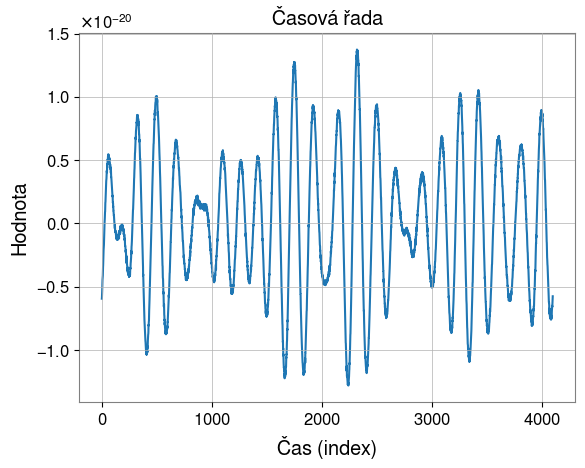

In [85]:
plt.plot(raw_d1)
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

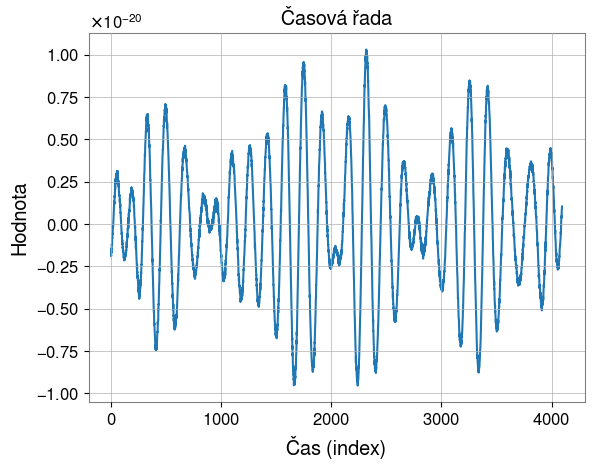

In [84]:
plt.plot(process[0])
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

In [32]:
def augment(x):
    # x: (3, T)

    # channel shuffle
    if torch.rand(1) < 0.3:
        idx = torch.randperm(3)
        x = x[idx]

    # small circular shift
    if torch.rand(1) < 0.5:
        shift = torch.randint(-20, 20, (1,))
        x = torch.roll(x, shifts=shift.item(), dims=-1)

    # time masking
    if torch.rand(1) < 0.5:
        l = x.shape[-1]
        t0 = torch.randint(0, l-50, (1,))
        t1 = t0 + torch.randint(20, 100, (1,))
        x[:, t0:t1] = 0

    return x

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Conv-BN-SiLU block
def conv_bn_silu(in_ch, out_ch, kernel_size, stride=1, padding=None):
    if padding is None:
        padding = kernel_size // 2  # keep same length
    return nn.Sequential(
        nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding),
        nn.BatchNorm1d(out_ch),
        nn.SiLU()
    )

class FastGWNet(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.block1 = conv_bn_silu(in_channels, 64, kernel_size=64)
        self.pool1 = nn.MaxPool1d(2)

        self.block2 = conv_bn_silu(64, 32, kernel_size=32)
        self.pool2 = nn.MaxPool1d(2)

        self.block3 = conv_bn_silu(32, 16, kernel_size=16)
        self.pool3 = nn.MaxPool1d(2)

        self.block4 = conv_bn_silu(16, 8, kernel_size=8)
        self.pool4 = nn.AdaptiveAvgPool1d(1)  # output: (batch, 8, 1)

        self.fc = nn.Linear(8, 1)  # single output for BCE

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.pool4(self.block4(x))
        x = x.squeeze(-1)  # remove last dimension (batch, 8, 1 -> batch, 8)
        x = self.fc(x)
        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 0
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.6933
Epoch 2: Loss = 0.6932
Epoch 3: Loss = 0.6932
Epoch 4: Loss = 0.6932
Epoch 5: Loss = 0.6932


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 1
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.5530
Epoch 2: Loss = 0.5185
Epoch 3: Loss = 0.5095
Epoch 4: Loss = 0.5040
Epoch 5: Loss = 0.4992


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 2
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.5637
Epoch 2: Loss = 0.5332
Epoch 3: Loss = 0.5243
Epoch 4: Loss = 0.5174
Epoch 5: Loss = 0.5120


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 3
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.5622
Epoch 2: Loss = 0.5302
Epoch 3: Loss = 0.5213
Epoch 4: Loss = 0.5141
Epoch 5: Loss = 0.5080


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 4
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.6932
Epoch 2: Loss = 0.6932
Epoch 3: Loss = 0.6932
Epoch 4: Loss = 0.6932
Epoch 5: Loss = 0.6932


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGWNet(in_channels=3).to(device)

# Example optimizer & scheduler
#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=0.1,
#    momentum=0.9,
#    weight_decay=1e-4,
#    nesterov=True
#)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer)#, T_max=40)

criterion = nn.BCEWithLogitsLoss()
EPOCHS = 40

dataset.process_number = 5
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(Xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")

Sample shape: torch.Size([3, 4096])
Label: 1.0
Epoch 1: Loss = 0.5642
Epoch 2: Loss = 0.5218
Epoch 3: Loss = 0.5123
Epoch 4: Loss = 0.5061
Epoch 5: Loss = 0.5015


In [33]:
device = "cuda"

model = GWNet().to(device)
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40,
    eta_min=1e-4
)

EPOCHS = 40

Epoch 1/40 - Loss: 4558.4685
Epoch 1: Loss = 0.5789
Epoch 2/40 - Loss: 4167.1592
Epoch 2: Loss = 0.5292
Epoch 3/40 - Loss: 4115.9822
Epoch 3: Loss = 0.5227
Epoch 4/40 - Loss: 4081.7617
Epoch 4: Loss = 0.5183
Epoch 5/40 - Loss: 4056.2493
Epoch 5: Loss = 0.5151
Epoch 6/40 - Loss: 4022.5821
Epoch 6: Loss = 0.5108
Epoch 7/40 - Loss: 4008.4863
Epoch 7: Loss = 0.5090
Epoch 8/40 - Loss: 3994.5330
Epoch 8: Loss = 0.5072
Epoch 9/40 - Loss: 3985.5525
Epoch 9: Loss = 0.5061
Epoch 10/40 - Loss: 3975.6860
Epoch 10: Loss = 0.5048

In [36]:


for epoch in range(30):
    model.train()
    total_loss = 0

    for X, y in train_loader:                        # X shape (B,3,T)
        X = X.to(device)
        y = y.to(device)

        # augment
        #X = torch.stack([augment(x) for x in X])
        X = torch.stack([augment(x) for x in X])  # batch shape: (batch_size, 3, 4096)

        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")
    if (epoch + 1) % 10 == 0:
        tag = f"epoch_{epoch+1:04d}"

        # 1️⃣ Save model weights only (recommended)
        torch.save(
            model.state_dict(),
            f"residual_model_least_process{tag}.pth"
        )

        # 2️⃣ Save FULL model (architecture + weights)
        torch.save(
            model,
            f"residual_model_full_least_process{tag}.pth"
        )

        # 3️⃣ Save full training checkpoint
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': total_loss,
        }, f"residual_checkpoint_least_process{tag}.pth")

Epoch 1/40 - Loss: 3965.0362
Epoch 1: Loss = 0.5035
Epoch 2/40 - Loss: 3955.0870
Epoch 2: Loss = 0.5022
Epoch 3/40 - Loss: 3943.8312
Epoch 3: Loss = 0.5008
Epoch 4/40 - Loss: 3925.8474
Epoch 4: Loss = 0.4985
Epoch 5/40 - Loss: 3905.7419
Epoch 5: Loss = 0.4960
Epoch 6/40 - Loss: 3894.5360
Epoch 6: Loss = 0.4945
Epoch 7/40 - Loss: 3871.3375
Epoch 7: Loss = 0.4916
Epoch 8/40 - Loss: 3841.6811
Epoch 8: Loss = 0.4878
Epoch 9/40 - Loss: 3825.6471
Epoch 9: Loss = 0.4858
Epoch 10/40 - Loss: 3815.6453
Epoch 10: Loss = 0.4845
Epoch 11/40 - Loss: 3801.2346
Epoch 11: Loss = 0.4827
Epoch 12/40 - Loss: 3788.7450
Epoch 12: Loss = 0.4811
Epoch 13/40 - Loss: 3778.8674
Epoch 13: Loss = 0.4799
Epoch 14/40 - Loss: 3764.8212
Epoch 14: Loss = 0.4781
Epoch 15/40 - Loss: 3745.2259
Epoch 15: Loss = 0.4756
Epoch 16/40 - Loss: 3734.8068
Epoch 16: Loss = 0.4743
Epoch 17/40 - Loss: 3722.1803
Epoch 17: Loss = 0.4727
Epoch 18/40 - Loss: 3701.7418
Epoch 18: Loss = 0.4701
Epoch 19/40 - Loss: 3692.7022
Epoch 19: Loss =

In [37]:
torch.save(
    model.state_dict(),
    f"residual_model_least_process_final.pth"
)

        # 2️⃣ Save FULL model (architecture + weights)
torch.save(
    model,
    f"residual_model_full_least_process_final.pth"
)

        # 3️⃣ Save full training checkpoint
torch.save({
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'loss': total_loss,
}, f"residual_checkpoint_least_process_final.pth")

In [29]:
#dataset = TimeSeriesDataset(
#    root_dir="g2net-gravitational-wave-detection/train/",
#    labels_csv="g2net-gravitational-wave-detection/training_labels.csv"
#)


dataset = TimeSeriesDataset(root_dir="g2net-gravitational-wave-detection/train/", 
                            labels_csv="g2net-gravitational-wave-detection/training_labels.csv",
                            return_raw_only=False, return_process_only=True)

In [30]:
# Check dataset size
print("Total samples:", len(dataset))

# Inspect a single item
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())


Total samples: 560000
Sample shape: torch.Size([3, 4096])
Label: 1.0


In [22]:
dataset.process_number = 0
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

Sample shape: torch.Size([3, 4096])
Label: 1.0


In [23]:
dataset.process_number = 1
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

Sample shape: torch.Size([3, 4096])
Label: 1.0


In [24]:
dataset.process_number = 2
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

Sample shape: torch.Size([3, 4096])
Label: 1.0


In [24]:
dataset.process_number = 3
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

Sample shape: torch.Size([3, 4096])
Label: 1.0


In [26]:
dataset.process_number = 4
X, y = dataset[0]
print("Sample shape:", X.shape)
print("Label:", y.item())

Sample shape: torch.Size([3, 4096])
Label: 1.0


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
from torch.utils.data import DataLoader, random_split
n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4)

In [40]:
# Get validation indices
val_indices = val_ds.indices

# Get corresponding file paths
val_files = [dataset.files[i] for i in val_indices]

# Optionally keep only base filenames
val_filenames = [os.path.basename(f) for f in val_files]



with open("val_files_fullpaths.txt", "w") as f:
    for path in val_files:
        f.write(path + "\n")

In [41]:
data_sinusoid = read_file("00000e74ad.npy")

In [42]:
import numpy as np

def estimate_frequency(x, fs):
    """
    x : 1D numpy array (signal)
    fs : sampling frequency (Hz)
    """
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    spectrum = np.abs(np.fft.rfft(x))

    # Ignore DC
    spectrum[0] = 0.0

    f = freqs[np.argmax(spectrum)]
    return f


In [43]:
def estimate_amplitude(x, f, fs):
    t = np.arange(len(x)) / fs
    s = np.sin(2 * np.pi * f * t)
    A = 2 * np.dot(x, s) / len(x)
    return np.abs(A)

In [44]:
def extract_A_f(x, fs):
    f = estimate_frequency(x, fs)
    A = estimate_amplitude(x, f, fs)
    return A, f

In [46]:
A1, f1 = extract_A_f(proc_sin1, fs)
A2, f2 = extract_A_f(proc_sin2, fs)
A3, f3 = extract_A_f(proc_sin3, fs)


In [47]:
def reconstruct(A, f, fs, n):
    t = np.arange(n) / fs
    return A * np.sin(2 * np.pi * f * t)

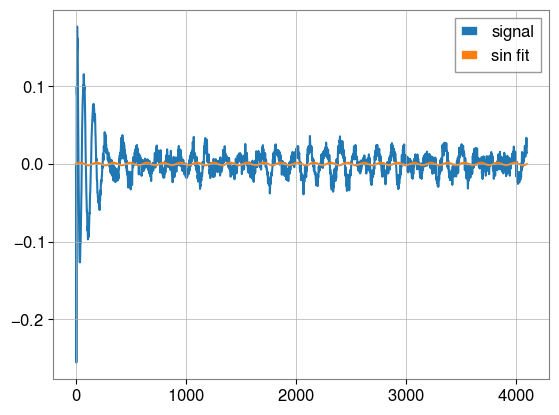

In [50]:
import matplotlib.pyplot as plt

y_hat = reconstruct(A1, f1, fs, len(proc_sin1))
plt.plot(proc_sin1, label="signal")
plt.plot(y_hat, label="sin fit")
plt.legend()
plt.show()

In [51]:
import numpy as np

def sine_model(t, A, omega):
    return A * np.sin(omega * t)

In [71]:
import numpy as np

def estimate_A(x, t, omega):
    s = np.sin(omega * t)
    return np.dot(x, s) / np.dot(s, s)

In [86]:
def loss_for_omega(omega, x, t):
    A = estimate_A(x, t, omega)
    A = 0.06
    pred = A * np.sin(omega * t)
    return np.mean((x - pred) ** 2)


In [100]:
from scipy.optimize import minimize_scalar

def fit_A_omega(x, t, fmin=20, fmax=500):
    res = minimize_scalar(
        lambda w: loss_for_omega(w, x, t),
        bounds=(2*np.pi*fmin, 2*np.pi*fmax),
        method="bounded"
    )

    omega_opt = res.x
    A_opt = 0.06
    A_opt = estimate_A(x, t, omega_opt)
    A_opt = 0.06
    return A_opt, omega_opt

In [101]:
t = np.arange(len(proc_sin1)) / fs
A1, omega1 = fit_A_omega(proc_sin1, t)

In [97]:
A1 = 0.1

In [103]:
print(omega1)

2449.6265496151696


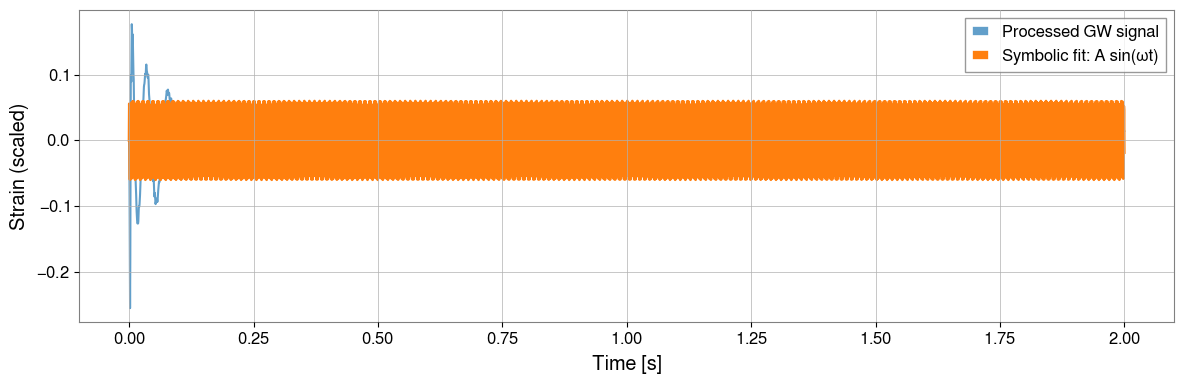

In [102]:
fitted = A1 * np.sin(omega1 * t)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(t, proc_sin1, label="Processed GW signal", alpha=0.7)
plt.plot(t, fitted, label="Symbolic fit: A sin(ωt)", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Strain (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from pysr import PySRRegressor

# ==========================================
# 1. SETUP
# ==========================================
fs = 2048.0  # Sample rate (Hz) - Adjust if different
time_vector = np.linspace(0, 1.0, 4096).reshape(-1, 1) # X must be 2D (rows, 1 column)

# ==========================================
# 2. THE TRIGGER (Your Model)
# ==========================================
prediction_prob = model.predict(sample_data.reshape(1, 3, 4096)) 

if prediction_prob > 0.95:
    print("Wave Detected! Starting Symbolic Regression...")
    
    # ==========================================
    # 3. APPLY SYMBOLIC REGRESSION
    # ==========================================
    sr_model = PySRRegressor(
        niterations=50,             # Increase to 100+ for better accuracy
        binary_operators=["*", "+"], # Allow multiply and add
        unary_operators=["sin"],    # We specifically look for sine waves
        variable_names=["t"],       # Name our input variable 't'
        maxsize=15,                 # Limit equation complexity
        verbosity=0                 # Silence output during training
    )

    results = []

    detector_names = ['H1', 'L1', 'V1']
    
    for i in range(3):
        channel_data = sample_data[i, :]
        
        sr_model.fit(time_vector, channel_data)
        
        best_eq = sr_model.sympy()
        results.append(best_eq)
        
        print(f"--- Detector {detector_names[i]} Equation ---")
        print(f"h(t) = {best_eq}")

else:
    print("No wave detected.")

In [114]:
fs = 2048.0
time_vector = np.linspace(0, 1.0, 4096).reshape(-1, 1)

In [119]:
import numpy as np
from pysr import PySRRegressor

sr_model = PySRRegressor(
        niterations=50,             # Increase to 100+ for better accuracy
        binary_operators=["*", "+", "^"], # Allow multiply and add
        unary_operators=["sin"],    # We specifically look for sine waves
        variable_names=["t"],       # Name our input variable 't'
        maxsize=15,                 # Limit equation complexity
        verbosity=0                 # Silence output during training
    )

results = []

detector_names = ['H1', 'L1', 'V1']
channel_data = proc_sin1

sr_model.fit(time_vector, channel_data)
        
best_eq = sr_model.sympy()
results.append(best_eq)

/home/pokorlu/venvs/ni-mvi/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/pokorlu/venvs/ni-mvi/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/pokorlu/venvs/ni-mvi/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


In [120]:
print(results)

[(x0**17.235685*1.5007886e-12)**(x0 + x0 + 0.001262716)]


In [16]:
import numpy as np
from scipy.optimize import curve_fit

def get_initial_guesses(t_segment, y_segment):
    # 1. Estimate Amplitude (Standard Deviation * sqrt(2) is a good proxy for Sine Amp)
    guess_A = np.std(y_segment) * np.sqrt(2)

    # 2. Estimate Frequency using FFT (Fast Fourier Transform)
    # This finds the "loudest" frequency in your window
    spectrum = np.fft.fft(y_segment)
    frequencies = np.fft.fftfreq(len(y_segment), d=(t_segment[1]-t_segment[0]))
    
    positive_freqs = frequencies[:len(frequencies)//2]
    positive_spectrum = np.abs(spectrum[:len(spectrum)//2])
    
    # Find the peak frequency
    peak_freq_index = np.argmax(positive_spectrum)
    peak_freq_hz = positive_freqs[peak_freq_index]
    
    # Convert to Angular Frequency (Omega)
    guess_omega = 2 * np.pi * peak_freq_hz
    
    # If FFT returns 0 (DC offset), force a fallback to LIGO's (100Hz)
    if guess_omega < 10.0: 
        guess_omega = 628.0 # Fallback to ~100 Hz

    return [guess_A, guess_omega, 0.0]

In [146]:
data_zero = read_file("00001f4945.npy")
proc_zero1, proc_zero2, proc_zero3 = preprocess(data_zero, 0)

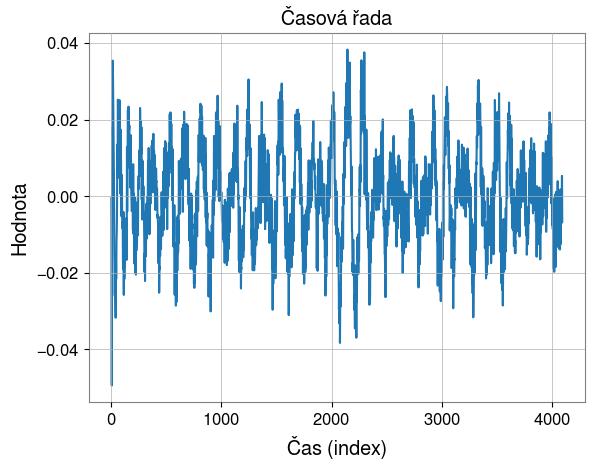

In [147]:
plt.plot(proc_zero1)
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

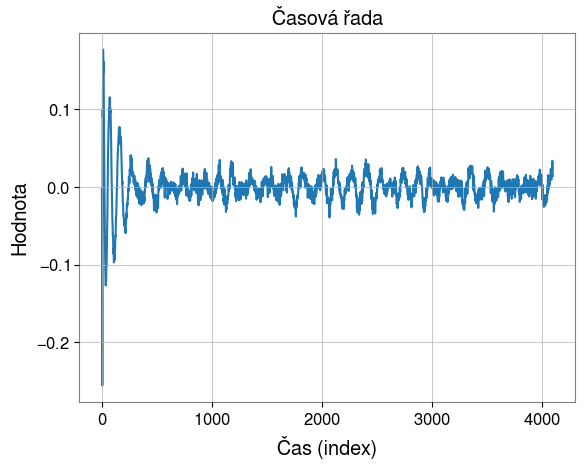

In [145]:
plt.plot(proc_sin1)
plt.xlabel("Čas (index)")
plt.ylabel("Hodnota")
plt.title("Časová řada")
plt.grid(True)
plt.show()

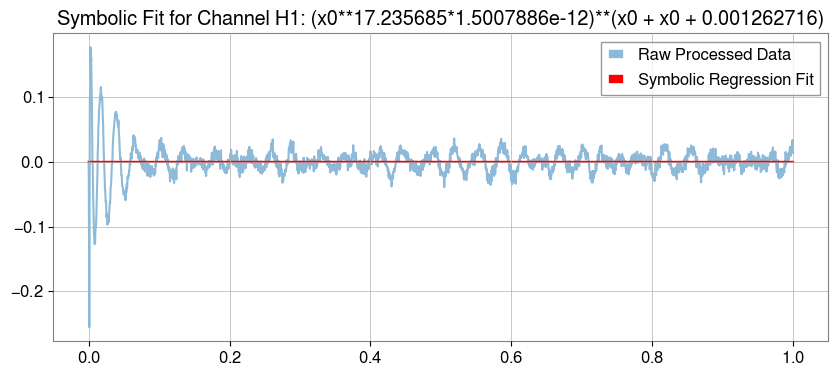

In [128]:
h1_pred = sr_model.predict(time_vector, index=0) # Index 0 gets the best equation

plt.figure(figsize=(10, 4))
plt.plot(time_vector, channel_data, label='Raw Processed Data', alpha=0.5)
plt.plot(time_vector, h1_pred, label='Symbolic Regression Fit', color='red')
plt.title(f"Symbolic Fit for Channel H1: {results[0]}")
plt.legend()
plt.show()

In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()

        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

In [27]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm  # Specialized progress bar for Jupyter
import os

# --- FILE PATHS ---
INPUT_FILE_LIST = "file.txt"        # Your text file with paths (one per line)
LABELS_CSV = "train_labels.csv"     # CSV with columns: [id, target]
OUTPUT_CSV = "grav_wave_analysis_results_full_tukey.csv"

# --- PHYSICS CONSTANTS ---
FS = 2048.0                       # Sampling Rate (Hz)
DURATION = 2.0                    # Duration (seconds)
N_POINTS = 4096                   # Number of data points
TIME_VECTOR = np.linspace(0, DURATION, N_POINTS)
DETECTORS = ['H1', 'L1', 'V1']    # Hanford, Livingston, Virgo

In [19]:
scaling = [1.5e-20, 1.5e-20, 0.5e-20]
def preprocess_scale(data, bandpass_number):#, bandpass=False, lf=20, hf=350,tukey=0.2):
    p1 = data[0]
    p2 = data[1]
    p3 = data[2]
    
    #bandpass(data, filter_settings = bandpass_number)
    #p1 = butter_highpass(d1)
    #p2 = butter_highpass(d2)
    #p3 = butter_highpass(d3)
    #scaling = tf.constant([1.5e-20, 1.5e-20, 0.5e-20], dtype=tf.float64)
    p1 = p1 / scaling[0]
    p2 = p2 / scaling[1]
    p3 = p3 / scaling[2]
    return p1, p2, p3

In [26]:
# 1. THE PHYSICS MODEL
def wave_model(t, A, omega, phase):
    return A * np.sin(omega * t + phase)

# 2. DATA LOADING & PREPROCESSING
def load_and_preprocess(file_path):
    data = read_file(file_path)
    p1, p2, p3 = preprocess(data, 0)
    stacked = np.stack([p1, p2, p3], axis=0)
    return stacked

def load_and_preprocess_scale(file_path):
    data = read_file(file_path)
    p1, p2, p3 = preprocess_scale(data, 0)
    stacked = np.stack([p1, p2, p3], axis=0)
    return stacked

def load_and_preprocess_full_tukey(file_path):
    data = read_file(file_path)
    p1, p2, p3 = preprocess_scale(data, 0)
    stacked = np.stack([p1, p2, p3], axis=0)
    return stacked

# 3. MODEL PREDICTION
def get_model_probability(processed_data):
    input_tensor = torch.tensor(processed_data).float()
    input_tensor = input_tensor.unsqueeze(0)
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        prob = torch.sigmoid(outputs).item()
    return prob

In [13]:
df_labels = pd.read_csv("g2net-gravitational-wave-detection/training_labels.csv")

# Convert to dict: {'000a5b6': 1, '000a5b7': 0, ...}
# Ensure the column names match your CSV (e.g., 'id', 'target')
true_labels_dict = pd.Series(df_labels.target.values, index=df_labels.id).to_dict()

print(f"Loaded {len(true_labels_dict)} labels.")

Loaded 560000 labels.


In [14]:
import torch

model = GWNet()
checkpoint_path = "residual_model_least_process_final.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
model.eval()
device = torch.device("cuda")
model.to(device)

print("Model loaded successfully via state_dict!")

/tmp/ipykernel_6053/4175753551.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))


Model loaded successfully via state_dict!


In [28]:

with open("val_files_fullpaths.txt", 'r') as f:
    file_paths = [line.strip() for line in f if line.strip()]

print(f"Found {len(file_paths)} files to process.")

results = []

# 2. Iterate with Progress Bar
for file_path in tqdm(file_paths, desc="Processing Files"):
    try:
        # --- A. Extract File ID ---
        # Assuming path is like ".../000a5b6.npy" -> "000a5b6"
        filename = file_path.split('/')[-1]   # Get last part
        file_id = filename.split('.')[0]      # Remove extension
        # --- B. Get Ground Truth (0 or 1) ---
        # Returns -1 if ID is not found in your CSV
        ground_truth = true_labels_dict.get(file_id, -1)
        # --- C. Load Data & Run Model ---
        data_3ch = load_and_preprocess(file_path)
        p_val = get_model_probability(data_3ch)

        for i in range(3):
            y_raw = data_3ch[i]
            
            # Initialize row with defaults (NaN)
            row = {
                'file_id': file_id,
                'detector': DETECTORS[i],
                'ground_truth': ground_truth, # Is it really a wave?
                'model_prob': p_val,          # Did your DL model think it's a wave?
                'fit_success': False,
                'A': np.nan,
                'omega': np.nan,
                'phase': np.nan,
                'snr': np.nan,
                'rmse': np.nan,
                'sigma_A': np.nan,
                'sigma_w': np.nan
            }
            try:
                # Initial Guess: A=1, w=628 (100Hz), phi=0
                #p0 = [1.0, 628.0, 0.0]
                p0 = get_initial_guesses(TIME_VECTOR, y_raw)
                # Run Optimization
                #params, pcov = curve_fit(wave_model, TIME_VECTOR, y_raw, p0=p0, maxfev=2000)
                params, pcov = curve_fit(wave_model, TIME_VECTOR, y_raw, p0=p0, 
                      bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]), maxfev=5000)
                # Extract Parameters
                A_fit, w_fit, phi_fit = params
                # Extract Uncertainty (Standard Deviation)
                perr = np.sqrt(np.diag(pcov)) 
                
                # Calculate Physics Metrics
                y_pred = wave_model(TIME_VECTOR, *params)
                residuals = y_raw - y_pred
                mse = mean_squared_error(y_raw, y_pred)
                rmse = np.sqrt(mse)
                noise_std = np.std(residuals)
                
                # Calculate SNR (Amplitude / Noise Floor)
                snr = abs(A_fit) / noise_std if noise_std > 1e-9 else 0.0
                # Save Valid Results
                row.update({
                    'fit_success': True,
                    'A': abs(A_fit),
                    'omega': w_fit,
                    'phase': phi_fit,
                    'snr': snr,
                    'rmse': rmse,
                    'sigma_A': perr[0],
                    'sigma_w': perr[1]
                })

            except (RuntimeError, ValueError):
                # Fit failed (likely pure noise), we leave values as NaN
                pass
            
            results.append(row)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        continue

print("Processing Complete.")

Found 56000 files to process.


Processing Files:   0%|          | 0/56000 [00:00<?, ?it/s]

Processing Complete.


In [29]:
# Create DataFrame
df = pd.DataFrame(results)

cols = ['file_id', 'detector', 'ground_truth', 'model_prob', 'fit_success', 
        'A', 'omega', 'snr', 'rmse', 'sigma_A', 'sigma_w']
df = df[cols]

df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved {len(df)} rows to {OUTPUT_CSV}")


df.head()

Saved 168000 rows to grav_wave_analysis_results_full_tukey.csv


,file_id,detector,ground_truth,model_prob,fit_success,A,omega,snr,rmse,sigma_A,sigma_w
0,a3482615d0,H1,1,0.192122,True,0.009928,88.626788,0.619879,0.016020,0.000353,0.062286
1,a3482615d0,L1,1,0.192122,True,0.008713,85.070135,0.713445,0.012213,0.000270,0.053866
2,a3482615d0,V1,1,0.192122,True,0.017828,125.641255,0.450569,0.039567,0.000875,0.084958
3,ba715aadb0,H1,1,0.999895,True,0.003635,90.160227,0.272254,0.013353,0.000295,0.140802
4,ba715aadb0,L1,1,0.999895,True,0.007657,124.511658,0.693339,0.011045,0.000244,0.055478


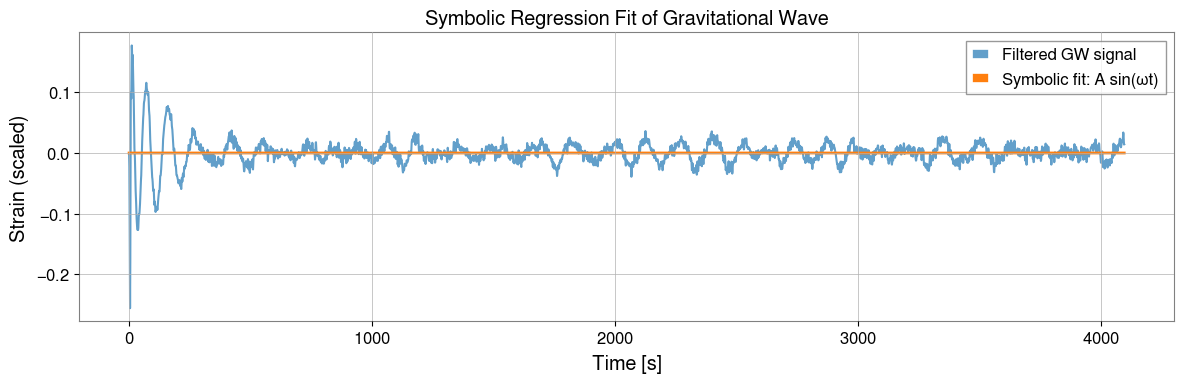

In [108]:
plt.figure(figsize=(12, 4))

plt.plot(t, proc_sin1, label="Filtered GW signal", alpha=0.7)
plt.plot(t, fitted, label="Symbolic fit: A sin(ωt)", linewidth=2)

plt.xlabel("Time [s]")
plt.ylabel("Strain (scaled)")
plt.title("Symbolic Regression Fit of Gravitational Wave")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

A1, f1 = fit_A_omega(proc_sin1)
A2, f2 = fit_A_omega(proc_sin2)
A3, f3 = fit_A_omega(proc_sin3)

In [19]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()

        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Validation Accuracy: 0.7494
F1 Score: 0.6906
ROC-AUC: 0.8133


Epoch 1, Loss: 0.69325, LR: 0.001000
Epoch 2, Loss: 0.69319, LR: 0.001000
Epoch 3, Loss: 0.69319, LR: 0.001000
Epoch 4, Loss: 0.69318, LR: 0.001000

I tried other models, but they didnt make much difference, the key to having good predictions is mostly good prehandling of data

In [19]:

model.train()
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        mean = inputs.mean(dim=2, keepdim=True)
        std = inputs.std(dim=2, keepdim=True)
        inputs = (inputs - mean) / (std + 1e-8)

        targets = targets.view(-1, 1).float()

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.5f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch 1, Loss: 0.69319, LR: 0.001000
Epoch 2, Loss: 0.69318, LR: 0.001000
Epoch 3, Loss: 0.69319, LR: 0.001000



KeyboardInterrupt



In [18]:
#saving
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'loss': avg_loss,
}, "inception_checkpoint_raw2.pth")

torch.save(model.state_dict(), "inception_model_raw2.pth")

In [16]:
#loading
model = InceptionTimeGW(input_channels=3, num_classes=1, base_channels=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

checkpoint = torch.load("inception_checkpoint_raw2.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

start_epoch = checkpoint['epoch'] + 1
loss_at_checkpoint = checkpoint['loss']

print(f"Resumed InceptionTime from epoch {start_epoch} with loss {loss_at_checkpoint:.5f}")

Resumed InceptionTime from epoch 1 with loss 0.69319


/tmp/ipykernel_5961/238843724.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("inception_checkpoint_raw2.pth", map_location=device)


residual 1DCNN where the inputs are raw data, unfiltered, unmodofied

In [18]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()

        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Validation Accuracy: 0.7477
F1 Score: 0.6697
ROC-AUC: 0.8375


In [38]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()

        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Validation Accuracy: 0.7769
F1 Score: 0.7296
ROC-AUC: 0.8398


In [70]:
torch.save(model.state_dict(), "residual_model_process_only46.pth")
torch.save(model, "residual_model_process_only46.pth")
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': total_loss,
}, "residual_checkpoint_process_only46.pth")

Residual 1DCNN with only raw data as input, the idea behind using only raw data for inputs is to get the parameters for symbolic regression in the form of Sine function, thus using filters and removing the waves of the simusoids would not be preffered, the only thing I can think of is using the filters to extract the information and then add that information to raw data, thus amplifying the chirp of a gravitational wave, but that raises a problem how to simulate such chirps, and that would require me to study difficult parts of physics for which I do not have time nor the will. The aproximation of these chirps could be in the way of white noise that has larger variance in some points of the time series of the gravitational wave.

Epoch 1: Loss = 0.6934

Epoch 2: Loss = 0.6933

Epoch 3: Loss = 0.6932

Epoch 4: Loss = 0.6932

Epoch 5: Loss = 0.6932

Epoch 6: Loss = 0.6932

Epoch 7: Loss = 0.6932

Epoch 8: Loss = 0.6932

Epoch 9: Loss = 0.6932

Epoch 10: Loss = 0.6932

Epoch 11: Loss = 0.6932

Epoch 12: Loss = 0.6932

Epoch 13: Loss = 0.6932

Epoch 14: Loss = 0.6932

Epoch 15: Loss = 0.6932

Epoch 16: Loss = 0.6932

Epoch 17: Loss = 0.6932

Epoch 18: Loss = 0.6932

Epoch 19: Loss = 0.6932

Epoch 20: Loss = 0.6931

Epoch 21: Loss = 0.6932

Epoch 22: Loss = 0.6931

Epoch 23: Loss = 0.6932

Epoch 24: Loss = 0.6932

Epoch 25: Loss = 0.6932

Epoch 26: Loss = 0.6932

Epoch 27: Loss = 0.6932

Epoch 28: Loss = 0.6932

Epoch 29: Loss = 0.6932

Epoch 30: Loss = 0.6932

Epoch 31: Loss = 0.6931

Epoch 32: Loss = 0.6932

Epoch 33: Loss = 0.6932

Epoch 34: Loss = 0.6932

Epoch 35: Loss = 0.6932

Epoch 36: Loss = 0.6932

Epoch 37: Loss = 0.6931

Epoch 38: Loss = 0.6932

Epoch 39: Loss = 0.6932

Epoch 40: Loss = 0.6931

residual 1DCNN epochs, with filtered, modified data and raw inputs:

Epoch 1: Loss = 0.6514

Epoch 2: Loss = 0.6100

Epoch 3: Loss = 0.6017

Epoch 4: Loss = 0.5965

Epoch 5: Loss = 0.5927

Epoch 6: Loss = 0.5897

Epoch 7: Loss = 0.5876

Epoch 8: Loss = 0.5857

Epoch 9: Loss = 0.5839

Epoch 10: Loss = 0.5821

Epoch 11: Loss = 0.5819

Epoch 12: Loss = 0.5800

Epoch 13: Loss = 0.5786

Epoch 14: Loss = 0.5771

Epoch 15: Loss = 0.5764

Epoch 16: Loss = 0.5751

Epoch 17: Loss = 0.5744

Epoch 18: Loss = 0.5734

Epoch 19: Loss = 0.5719

Epoch 20: Loss = 0.5716

Epoch 21: Loss = 0.5709

Epoch 22: Loss = 0.5697

Epoch 23: Loss = 0.5692

Epoch 24: Loss = 0.5684

Epoch 25: Loss = 0.5678

1DCNN, with 6 inputs raw and modified, after this training I decided to scale the model to be more complex

epoch 1

epoch 2

Epoch 3: Loss = 0.6514

Epoch 4: Loss = 0.6379

Epoch 5: Loss = 0.6284

Epoch 6: Loss = 0.6241

Epoch 7: Loss = 0.6225

Epoch 8: Loss = 0.6198

Epoch 9: Loss = 0.6173

Epoch 10: Loss = 0.6155

Epoch 11: Loss = 0.6143

Epoch 12: Loss = 0.6138

Epoch 13: Loss = 0.6133

Epoch 14: Loss = 0.6113

Epoch 15: Loss = 0.6105

Epoch 16: Loss = 0.6094

Epoch 17: Loss = 0.6086

Epoch 18: Loss = 0.6076

Epoch 19: Loss = 0.6072

Epoch 20: Loss = 0.6056

Epoch 21: Loss = 0.6047

Epoch 22: Loss = 0.6045

Epoch 23: Loss = 0.6035

Epoch 24: Loss = 0.6028

Epoch 25: Loss = 0.6030

In [44]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()

        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Validation Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Validation Accuracy: 0.6138
F1 Score: 0.6645
ROC-AUC: 0.7169


25 process + raw: F1 0.6645, ROC AUC 0.7169, VA 0.6138

25 F1 0.6545, ROC AUC 0.6996 VA - 0.6005

6 F1 0.6399, ROC AUC 0.6765, VA - 0.5959

In [19]:
torch.save(model.state_dict(), "residual_model_process_best_10.pth")
torch.save(model, "residual_model_process_best_10.pth")
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),   # <-- add this
    'loss': total_loss,
}, "residual_checkpoint_process_best_10.pth")

In [ ]:
checkpoint = torch.load("residual_checkpoint_process_best_10.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

25 - F1 0.6667 VA 0.5000, ROC-AUC 0.6687